<a href="https://colab.research.google.com/github/VirajAdake210706/AI-based-Alternate-credit-scoring/blob/main/edi2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, precision_score, recall_score
from sklearn.ensemble import GradientBoostingClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek  # Cleaner oversampling

# 1. LOAD DATA
df = pd.read_csv("/content/cs-training.csv")
y = df["SeriousDlqin2yrs"]

# 2. SELECT FEATURES & ENGINEER
X = df[[
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans"
]].copy()

# 3. HANDLE MISSING & OUTLIERS
X = X.fillna(X.median())

# Clip outliers (using 1% and 99% for slightly more stability)
for col in X.columns:
    X[col] = X[col].clip(X[col].quantile(0.01), X[col].quantile(0.99))

# 4. ENHANCED FEATURE ENGINEERING
X["DebtIncomeRatio"] = X["DebtRatio"] / (X["MonthlyIncome"] + 1)
X["LateSeverity"] = (X["NumberOfTime30-59DaysPastDueNotWorse"] * 1 + X["NumberOfTimes90DaysLate"] * 3)
X["ZeroIncomeFlag"] = (X["MonthlyIncome"] == 0).astype(int)
X["HighUtilization"] = (X["RevolvingUtilizationOfUnsecuredLines"] > 0.9).astype(int)

# 5. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 6. PREPROCESSING
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), X.columns)
])

# 7. REFINED PIPELINE
# Using SMOTETomek to reduce noise and a slightly deeper GBT
pipeline = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote_tomek", SMOTETomek(sampling_strategy=0.6, random_state=42)),
    ("model", GradientBoostingClassifier(
        n_estimators=800,       # More trees for finer detail
        learning_rate=0.03,     # Slower learning for precision
        max_depth=4,            # Capture more complex interactions
        subsample=0.8,
        min_samples_leaf=50,
        random_state=42
    ))
])

# 8. TRAIN
pipeline.fit(X_train, y_train)

# 9. PROBABILITY PREDICTION
y_prob = pipeline.predict_proba(X_test)[:,1]

# 10. TARGETED THRESHOLD SEARCH
# We are hunting for the highest precision given a Recall floor of ~0.68-0.70
best_threshold = 0.5
max_precision = 0
target_recall = 0.69 # Set our minimum acceptable recall

for t in np.arange(0.20, 0.60, 0.005):
    y_temp = (y_prob >= t).astype(int)
    prec = precision_score(y_test, y_temp, zero_division=0)
    rec = recall_score(y_test, y_temp)

    # Logic: If we meet the recall goal, find the highest precision within that set
    if rec >= target_recall:
        if prec > max_precision:
            max_precision = prec
            best_threshold = t

# 11. FINAL EVALUATION
y_pred = (y_prob >= best_threshold).astype(int)

print(f"--- Optimized Results (Target Recall: {target_recall}) ---")
print(f"Best Threshold: {best_threshold:.4f}")
print(classification_report(y_test, y_pred))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob):.4f}")

--- Optimized Results (Target Recall: 0.69) ---
Best Threshold: 0.2300
              precision    recall  f1-score   support

           0       0.97      0.85      0.91     27995
           1       0.25      0.70      0.36      2005

    accuracy                           0.84     30000
   macro avg       0.61      0.77      0.63     30000
weighted avg       0.93      0.84      0.87     30000

ROC AUC: 0.8553


['refined_credit_model.pkl']

In [16]:
# 12. SAVE
joblib.dump(pipeline, "refined_credit_model.pkl")

['refined_credit_model.pkl']

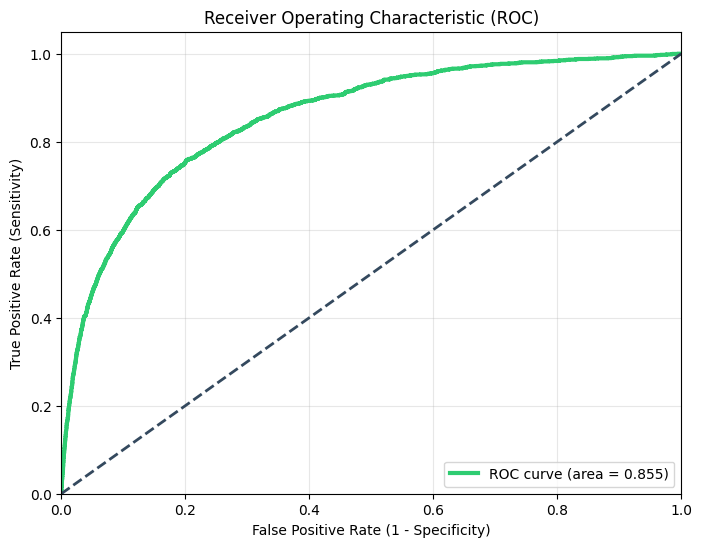

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#2ecc71', lw=3, label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='#34495e', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

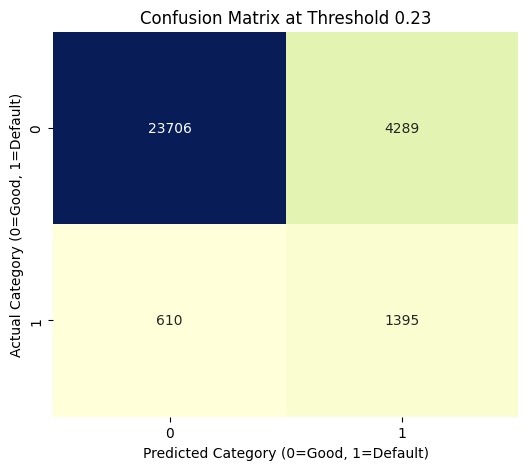

In [14]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Using the best_threshold calculated previously
y_pred_final = (y_prob >= best_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', cbar=False)
plt.title(f'Confusion Matrix at Threshold {best_threshold:.2f}')
plt.ylabel('Actual Category (0=Good, 1=Default)')
plt.xlabel('Predicted Category (0=Good, 1=Default)')
plt.show()

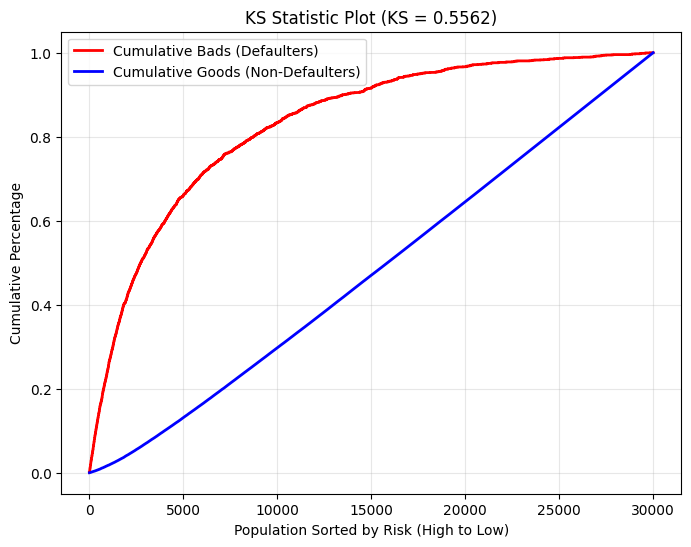

Final KS Statistic: 0.5562


In [15]:
def calculate_ks(y_true, y_probs):
    # Create a dataframe for calculations
    df_ks = pd.DataFrame({'label': y_true, 'prob': y_probs})
    df_ks = df_ks.sort_values(by='prob', ascending=False)

    # Calculate cumulative percent of total Goods and Bads
    df_ks['is_real_bad'] = df_ks['label']
    df_ks['is_real_good'] = 1 - df_ks['label']

    df_ks['cum_bad'] = df_ks['is_real_bad'].cumsum() / df_ks['is_real_bad'].sum()
    df_ks['cum_good'] = df_ks['is_real_good'].cumsum() / df_ks['is_real_good'].sum()

    # KS is the max difference between the two distributions
    df_ks['ks_diff'] = abs(df_ks['cum_bad'] - df_ks['cum_good'])
    ks_stat = df_ks['ks_diff'].max()

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.plot(df_ks['cum_bad'].values, label='Cumulative Bads (Defaulters)', color='red', lw=2)
    plt.plot(df_ks['cum_good'].values, label='Cumulative Goods (Non-Defaulters)', color='blue', lw=2)
    plt.title(f'KS Statistic Plot (KS = {ks_stat:.4f})')
    plt.xlabel('Population Sorted by Risk (High to Low)')
    plt.ylabel('Cumulative Percentage')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return ks_stat

ks_value = calculate_ks(y_test, y_prob)
print(f"Final KS Statistic: {ks_value:.4f}")